In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Ruta base en Drive
DRIVE_BASE = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2'
DATA_FILE  = f'{DRIVE_BASE}/Data/input-2-.txt'
CKPT_SCRATCH = f'{DRIVE_BASE}/gpt_scratch_checkpoint.pt'
CKPT_FT      = f'{DRIVE_BASE}/gpt2_finetuned_checkpoint.pt'
FT_OUTPUT_DIR = f'{DRIVE_BASE}/gpt2-finetuned'

Mounted at /content/drive


# 1. GPT desde cero

Implementación de una arquitectura GPT entrenada sobre el corpus de Shakespeare,
usando el tokenizer de GPT-2 (vocabulario de 50 257 tokens).

## 1.1 Librerías e hiperparámetros

In [2]:
import tiktoken
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Reproducibilidad
seed = 99
torch.manual_seed(seed)
np.random.seed(seed)

# Hiperparámetros
block_size  = 64    # Longitud del contexto (tokens)
batch_size  = 64    # Ejemplos por lote
model_dim   = 512   # Dimensión del embedding
heads_num   = 8     # Cabezas de atención
blocks_num  = 4     # Bloques transformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo: {device}')

Dispositivo: cuda


## 1.2 Tokenizer GPT-2

In [3]:
# Cargar el tokenizer de GPT-2 (vocabulario de 50 257 tokens)
tokenizer = tiktoken.encoding_for_model('gpt-2')
vocab_size = tokenizer.n_vocab
print(f'Tamaño del vocabulario: {vocab_size:,}')

encode = lambda text: tokenizer.encode(text)
decode = lambda ids: tokenizer.decode(ids)

Tamaño del vocabulario: 50,257


## 1.3 Carga y preparación del corpus

In [4]:
with open(DATA_FILE, encoding='utf-8') as f:
    corpus_text = f.read()

print(f'Longitud del corpus: {len(corpus_text):,} caracteres')
print('--- Muestra ---')
print(corpus_text[:200])

Longitud del corpus: 1,115,394 caracteres
--- Muestra ---
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [5]:
# Tokenizar el corpus completo con el tokenizer de GPT-2
encoded_corpus = encode(corpus_text)
print(f'Tokens totales: {len(encoded_corpus):,}')

# División 90% entrenamiento / 10% validación
k = int(len(encoded_corpus) * 0.9)
train_corpus = encoded_corpus[:k]
val_corpus   = encoded_corpus[k:]
print(f'Train: {len(train_corpus):,} tokens')
print(f'Val:   {len(val_corpus):,} tokens')

Tokens totales: 338,025
Train: 304,222 tokens
Val:   33,803 tokens


## 1.4 DataLoader

In [6]:
class DataLoader:
    """Itera el corpus en lotes de secuencias de tamaño block_size."""
    def __init__(self, corpus, block_size):
        self.corpus = torch.tensor(corpus, dtype=torch.long)
        self.block_size = block_size
        self.examples_index = list(range(0, len(corpus) - block_size, block_size))
        self.order = np.random.permutation(self.examples_index)
        self.curr_pos = 0
        self.stride = 0

    def get_batch(self, batch_size):
        batch_examples = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_examples)

        # Cuando se agota el corpus, reiniciar con distinto stride
        if len(batch_examples) < batch_size:
            self.curr_pos = 0
            self.stride = (self.stride + 1) % self.block_size
            self.examples_index = list(range(self.stride, len(self.corpus) - self.block_size, self.block_size))
            self.order = np.random.permutation(self.examples_index)
            if len(batch_examples) == 0:
                batch_examples = self.order[self.curr_pos : self.curr_pos + batch_size]
                self.curr_pos += len(batch_examples)

        x = torch.stack([self.corpus[i : i + self.block_size]         for i in batch_examples])
        y = torch.stack([self.corpus[i + 1 : i + 1 + self.block_size] for i in batch_examples])
        return x, y

## 1.5 Arquitectura GPT

In [7]:
class SelfAttention(nn.Module):
    """Una cabeza de atención causal (masked self-attention)."""
    def __init__(self, embed_dim, head_dim, block_size):
        super().__init__()
        self.head_dim = head_dim
        self.Wq = nn.Linear(embed_dim, head_dim, bias=False)
        self.Wk = nn.Linear(embed_dim, head_dim, bias=False)
        self.Wv = nn.Linear(embed_dim, head_dim, bias=False)
        # Máscara triangular para que cada token sólo atienda tokens pasados
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):  # x: [N, T, D]
        N, T, D = x.shape
        Q = self.Wq(x)  # [N, T, head_dim]
        K = self.Wk(x)
        V = self.Wv(x)
        att = Q @ K.transpose(-1, -2) * self.head_dim ** -0.5  # [N, T, T]
        att = att.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        return att @ V  # [N, T, head_dim]


class MultiHeadAttention(nn.Module):
    def __init__(self, heads_num, embed_dim, head_dim, block_size):
        super().__init__()
        self.heads = nn.ModuleList([
            SelfAttention(embed_dim, head_dim // heads_num, block_size)
            for _ in range(heads_num)
        ])
        self.dense = nn.Linear(head_dim, head_dim, bias=False)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # concatenar todas las cabezas
        return self.dense(out)


class FeedForward(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.dense1 = nn.Linear(in_dim, hidden_dim)
        self.dense2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.dense2(F.relu(self.dense1(x)))


class Block(nn.Module):
    """Bloque Transformer: Multi-Head Attention + Feed Forward con conexiones residuales."""
    def __init__(self, heads_num, model_dim, block_size):
        super().__init__()
        self.attention = MultiHeadAttention(heads_num, model_dim, model_dim, block_size)
        self.ln1  = nn.LayerNorm(model_dim)
        self.ffd  = FeedForward(model_dim, model_dim * 4, model_dim)
        self.ln2  = nn.LayerNorm(model_dim)
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        x = self.ln1(x + self.drop1(self.attention(x)))  # residual + layer norm
        x = self.ln2(x + self.drop2(self.ffd(x)))
        return x


class GPT(nn.Module):
    """Arquitectura GPT completa: token embedding + positional embedding + N bloques + cabeza de predicción."""
    def __init__(self, vocab_size, model_dim, block_size, blocks_num, heads_num):
        super().__init__()
        self.E    = nn.Embedding(vocab_size, model_dim)   # Token embeddings
        self.posE = nn.Embedding(block_size, model_dim)   # Positional embeddings
        self.ln1  = nn.LayerNorm(model_dim)
        self.drop = nn.Dropout(0.1)
        self.blocks = nn.Sequential(*[
            Block(heads_num, model_dim, block_size) for _ in range(blocks_num)
        ])
        self.head = nn.Linear(model_dim, vocab_size, bias=False)

    def forward(self, x):  # x: [N, T]
        positions = torch.arange(x.shape[1], device=x.device)
        emb = self.E(x) + self.posE(positions)  # [N, T, D] — suma token + posición
        emb = self.drop(self.ln1(emb))
        emb = self.blocks(emb)                  # [N, T, D]
        return self.head(emb)                   # [N, T, vocab_size]


model = GPT(vocab_size, model_dim, block_size, blocks_num, heads_num).to(device)
print(f'Parámetros del modelo: {sum(p.numel() for p in model.parameters()):,}')
model

Parámetros del modelo: 64,098,304


GPT(
  (E): Embedding(50257, 512)
  (posE): Embedding(64, 512)
  (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (drop): Dropout(p=0.1, inplace=False)
  (blocks): Sequential(
    (0): Block(
      (attention): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x SelfAttention(
            (Wq): Linear(in_features=512, out_features=64, bias=False)
            (Wk): Linear(in_features=512, out_features=64, bias=False)
            (Wv): Linear(in_features=512, out_features=64, bias=False)
          )
        )
        (dense): Linear(in_features=512, out_features=512, bias=False)
      )
      (ln1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (ffd): FeedForward(
        (dense1): Linear(in_features=512, out_features=2048, bias=True)
        (dense2): Linear(in_features=2048, out_features=512, bias=True)
      )
      (ln2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (drop1): Dropout(p=0.1, inplace=False)
      (drop2): Drop

## 1.6 Entrenamiento

In [8]:
@torch.no_grad()
def estimate_loss(model, train_eval, val_eval, eval_iters=10):
    model.eval()
    results = {}
    for name, loader in [('train', train_eval), ('val', val_eval)]:
        losses = []
        for _ in range(eval_iters):
            x, y = loader.get_batch(batch_size)
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            losses.append(loss.item())
        results[name] = sum(losses) / eval_iters
    model.train()
    return results['train'], results['val']


def training_loop(model, lr, max_steps, data_loader, train_eval, val_eval,
                  weight_decay=0.0, steps_per_log=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []

    model.train()
    print(f'Entrenando por {max_steps} pasos...')
    for step in range(max_steps):
        x, y = data_loader.get_batch(batch_size)
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (step + 1) % steps_per_log == 0 or step == 0 or step == max_steps - 1:
            tl, vl = estimate_loss(model, train_eval, val_eval)
            print(f'Step {step+1:5d} | train loss: {tl:.4f} | val loss: {vl:.4f}')
            train_losses.append(tl)
            val_losses.append(vl)

    return train_losses, val_losses

In [9]:
train_data = DataLoader(train_corpus, block_size)
val_data   = DataLoader(val_corpus,   block_size)

steps_per_epoch = len(train_data.examples_index) // batch_size
print(f'Pasos por época: {steps_per_epoch}')

train_losses, val_losses = training_loop(
    model,
    lr=3e-4,
    max_steps=20 * steps_per_epoch,
    data_loader=train_data,
    train_eval=DataLoader(train_corpus, block_size),
    val_eval=DataLoader(val_corpus, block_size),
    weight_decay=1e-4,
    steps_per_log=steps_per_epoch
)

# Perplexity final
import math
_, final_val_loss = estimate_loss(model, DataLoader(train_corpus, block_size), DataLoader(val_corpus, block_size))
perplexity_exp1 = math.exp(final_val_loss) if final_val_loss < 20 else float('inf')
print(f'Val loss:   {final_val_loss:.4f}')
print(f'Perplexity: {perplexity_exp1:.4f}')

Pasos por época: 74
Entrenando por 1480 pasos...
Step     1 | train loss: 9.8554 | val loss: 9.8004
Step    74 | train loss: 5.7331 | val loss: 5.8806
Step   148 | train loss: 5.0599 | val loss: 5.3480
Step   222 | train loss: 4.6420 | val loss: 5.0067
Step   296 | train loss: 4.4401 | val loss: 4.8372
Step   370 | train loss: 4.2102 | val loss: 4.7554
Step   444 | train loss: 4.1446 | val loss: 4.6325
Step   518 | train loss: 3.9996 | val loss: 4.6594
Step   592 | train loss: 3.9226 | val loss: 4.6231
Step   666 | train loss: 3.8216 | val loss: 4.5966
Step   740 | train loss: 3.7175 | val loss: 4.5552
Step   814 | train loss: 3.6245 | val loss: 4.5241
Step   888 | train loss: 3.5537 | val loss: 4.5419
Step   962 | train loss: 3.4543 | val loss: 4.5357
Step  1036 | train loss: 3.4351 | val loss: 4.5548
Step  1110 | train loss: 3.3291 | val loss: 4.4998
Step  1184 | train loss: 3.2931 | val loss: 4.5701
Step  1258 | train loss: 3.1989 | val loss: 4.5542
Step  1332 | train loss: 3.1782 |

In [10]:
# Guardar checkpoint del modelo scratch (requerido por la rúbrica)
torch.save(model.state_dict(), CKPT_SCRATCH)
print(f'Checkpoint guardado: {CKPT_SCRATCH}')

Checkpoint guardado: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/gpt_scratch_checkpoint.pt


## 1.7 Curvas de pérdida

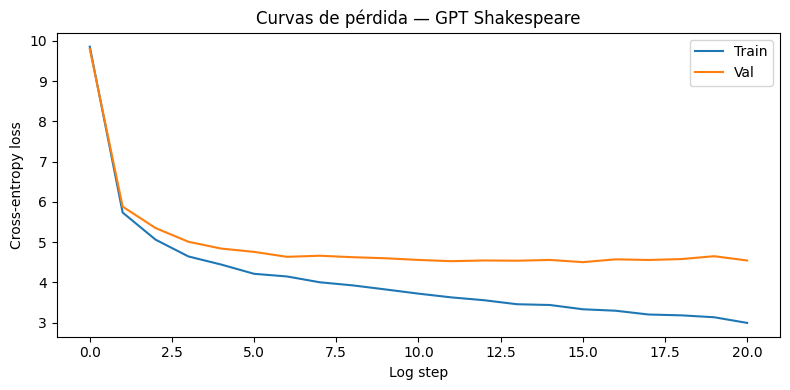

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Log step')
plt.ylabel('Cross-entropy loss')
plt.title('Curvas de pérdida — GPT Shakespeare')
plt.legend()
plt.tight_layout()
plt.show()

## 1.8 Generación de texto

In [12]:
@torch.no_grad()
def generate(model, seed: torch.tensor, max_tokens=300, max_context=block_size, temperature=0.8, top_p=0.9):
    """Generación de texto desde cero — nucleus sampling (top-p)."""
    model.eval()
    generation = seed.clone().to(device)

    for _ in range(max_tokens):
        pred = model(generation[:, -max_context:])[:, -1, :]
        pred = pred / temperature
        probs = F.softmax(pred, dim=-1)

        if top_p == 1:
            next_tok = torch.multinomial(probs, 1, replacement=True)
            generation = torch.cat((generation, next_tok), dim=1)
        else:
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            cutoff = cumulative_probs <= top_p
            top_p_probs = sorted_probs[cutoff]
            top_p_probs = top_p_probs / top_p_probs.sum()
            if len(top_p_probs) == 0:
                probs = F.softmax(pred, dim=-1)
                next_tok = torch.multinomial(probs, 1)
            else:
                next_tok = torch.multinomial(top_p_probs, 1)
                next_tok = (sorted_indices[0][next_tok]).unsqueeze(0)
            generation = torch.cat((generation, next_tok), dim=1)

    return decode(generation[0].tolist())


# 3 ejemplos con distintos prompts
prompts_scratch = [
    "KING:\n",
    "HAMLET:\nTo be or not to be.\n\nKING:\n",
    "All:\nSpeak, speak.\n\nFirst Citizen:\n",
]

for i, prompt in enumerate(prompts_scratch, 1):
    seed = torch.tensor([encode(prompt)], dtype=torch.long)
    print(f"=== Ejemplo {i} ===")
    print(generate(model, seed, max_tokens=200, temperature=0.8, top_p=0.9))
    print()


=== Ejemplo 1 ===
KING:
I am too sudden.

KING RICHARD III:
I would thou know'st me, though I wot not my heart
To bid them both with wits: but what they say
'Twas not so then he is not loathsome,
And that he had been sad stories; and 'tis, nothing
The violent is made and yet it is not fourteen.

BRUTUS:
I had not, sir, you hear me
That's goodly work, the general is't, but it is
That he is very goodly.

SICINIUS:
I have you
That you would have been a mile before
Where and be consul, is the city of,
You shall not pass, but being members,
And Rome,--what,
Of what witchcraft's,--what, sir, what,
You shall not spend me in my nature,
Even so, my noble

=== Ejemplo 2 ===
HAMLET:
To be or not to be.

KING:
I am a plain man, is it is as well as nought as a subject,
When she could seem to her blood, as thou art,
Which, with a king, a king is lost.

PETRUCHIO:
Good my knowledge, master's true,
That it is a simple is a divine tale.

PETRUCHIO:
'Tis very good; and I am.

MERCUTIO:
I pray thee, thin

# 2. Finetuning de GPT-2

Carga del modelo GPT-2 preentrenado (124M parámetros) y finetuning
sobre el corpus de Shakespeare usando la librería `transformers` de Hugging Face.

## 2.1 Setup, datos y entrenamiento

In [13]:
# pip install transformers datasets accelerate evaluate

import math
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

# =========================================================
# 1. Configuración
# =========================================================
MODEL_NAME = "gpt2"              # puedes cambiar a "distilgpt2" si quieres algo más liviano
TEXT_FILE = DATA_FILE
OUTPUT_DIR = FT_OUTPUT_DIR
BLOCK_SIZE = 128                 # GPT-2 soporta hasta 1024 tokens, pero 128/256 consume menos memoria
TRAIN_RATIO = 0.9
SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

# =========================================================
# 2. Cargar texto
# =========================================================
with open(DATA_FILE, "r", encoding="utf-8") as f:
    text = f.read()

if len(text.strip()) == 0:
    raise ValueError("El archivo de texto está vacío.")

# =========================================================
# 3. Tokenizer y modelo
# =========================================================
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# GPT-2 no trae pad_token por defecto; una práctica común es usar eos_token como pad_token.
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token

ft_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
ft_model.config.pad_token_id = ft_tokenizer.pad_token_id

print(f'Parámetros GPT-2: {sum(p.numel() for p in ft_model.parameters()):,}')

# =========================================================
# 4. Crear dataset simple desde el texto
# =========================================================
# Si tienes muchos documentos, aquí conviene usar una lista de textos, no uno solo.
raw_dataset = Dataset.from_dict({"text": [text]})

# =========================================================
# 5. Tokenización
# =========================================================
def tokenize_function(examples):
    return ft_tokenizer(examples["text"])

tokenized_dataset = raw_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"],
)

# =========================================================
# 6. Agrupar en bloques para causal LM
# =========================================================
def group_texts(examples):
    # concatenar todos los ejemplos tokenizados
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples["input_ids"])

    # recortar para que sea múltiplo de BLOCK_SIZE
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE

    result = {
        k: [t[i:i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated_examples.items()
    }

    # En causal LM, labels = input_ids
    result["labels"] = result["input_ids"].copy()
    return result

lm_dataset = tokenized_dataset.map(
    group_texts,
    batched=True,
)

# =========================================================
# 7. Split train / validation
# =========================================================
split_dataset = lm_dataset.train_test_split(test_size=1 - TRAIN_RATIO, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print("Ejemplos train:", len(train_dataset))
print("Ejemplos val:", len(eval_dataset))

if len(train_dataset) == 0 or len(eval_dataset) == 0:
    raise ValueError(
        "Muy pocos datos después de agrupar en bloques. "
        "Prueba con un texto más largo o un BLOCK_SIZE menor."
    )

# =========================================================
# 8. Data collator
# =========================================================
# Para GPT-2 causal LM debe ir mlm=False
data_collator = DataCollatorForLanguageModeling(
    tokenizer=ft_tokenizer,
    mlm=False,
)

# =========================================================
# 9. Argumentos de entrenamiento
# =========================================================
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    # entrenamiento
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    # optimización
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",

    # evaluación / guardado
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=20,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # estabilidad
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

# =========================================================
# 10. Trainer
# =========================================================
trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

# =========================================================
# 11. Entrenamiento
# =========================================================
trainer.train()

# =========================================================
# 12. Evaluación
# =========================================================
eval_results = trainer.evaluate()
eval_loss = eval_results["eval_loss"]
perplexity = math.exp(eval_loss) if eval_loss < 20 else float("inf")

print(f"Eval loss: {eval_loss:.4f}")
print(f"Perplexity: {perplexity:.4f}")

# =========================================================
# 13. Guardar modelo final
# =========================================================
trainer.save_model(OUTPUT_DIR)
ft_tokenizer.save_pretrained(OUTPUT_DIR)


Dispositivo: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Eval loss: 3.4619
Perplexity: 31.8780


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/gpt2-finetuned/tokenizer_config.json',
 '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/gpt2-finetuned/tokenizer.json')

In [14]:
# Guardar checkpoint del modelo finetuned (requerido por la rúbrica)
torch.save(ft_model.state_dict(), CKPT_FT)
print(f'Checkpoint guardado: {CKPT_FT}')

Checkpoint guardado: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2/gpt2_finetuned_checkpoint.pt


## 2.2 Curvas de pérdida

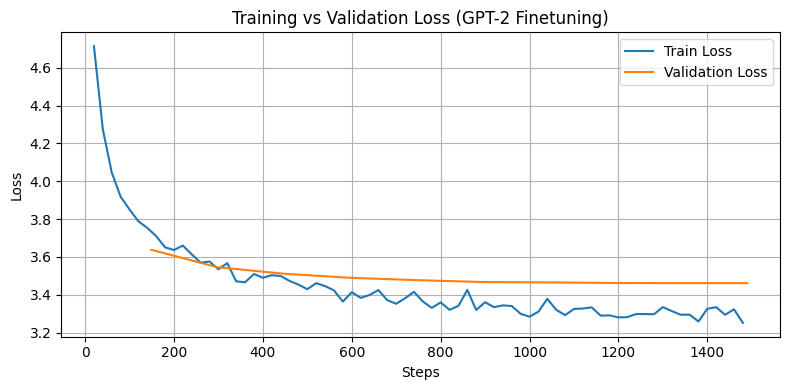

In [15]:
import matplotlib.pyplot as plt

# =========================================================
# EXTRA: Extraer logs y graficar
# =========================================================
log_history = trainer.state.log_history

train_loss = []
eval_loss = []
steps_train = []
steps_eval = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_loss.append(log["loss"])
        steps_train.append(log["step"])
    if "eval_loss" in log:
        eval_loss.append(log["eval_loss"])
        steps_eval.append(log["step"])

# =========================================================
# Graficar
# =========================================================
plt.figure(figsize=(8, 4))

plt.plot(steps_train, train_loss, label="Train Loss")
plt.plot(steps_eval, eval_loss, label="Validation Loss")

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (GPT-2 Finetuning)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## 2.3 Generación de texto

In [16]:
@torch.no_grad()
def ft_generate(model, tokenizer, seed: torch.tensor, max_tokens=300, max_context=BLOCK_SIZE, temperature=0.8, top_p=0.9):
    """Generación desde cero para modelo finetuneado — mismo patrón que scratch.
    Única diferencia: model() devuelve un objeto con .logits en vez de logits directamente."""
    model.eval()
    generation = seed.clone().to(device)

    for _ in range(max_tokens):
        pred = model(input_ids=generation[:, -max_context:]).logits[:, -1, :]  # .logits
        pred = pred / temperature
        probs = torch.nn.functional.softmax(pred, dim=-1)

        if top_p == 1:
            next_tok = torch.multinomial(probs, 1, replacement=True)
            generation = torch.cat((generation, next_tok), dim=1)
        else:
            sorted_probs, sorted_indices = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            cutoff = cumulative_probs <= top_p
            top_p_probs = sorted_probs[cutoff]
            top_p_probs = top_p_probs / top_p_probs.sum()
            if len(top_p_probs) == 0:
                probs = torch.nn.functional.softmax(pred, dim=-1)
                next_tok = torch.multinomial(probs, 1)
            else:
                next_tok = torch.multinomial(top_p_probs, 1)
                next_tok = (sorted_indices[0][next_tok]).unsqueeze(0)
            generation = torch.cat((generation, next_tok), dim=1)

    return tokenizer.decode(generation[0].tolist())


# Mismos 3 prompts que scratch para comparación directa
prompts_ft = [
    "KING:\n",
    "HAMLET:\nTo be or not to be.\n\nKING:\n",
    "All:\nSpeak, speak.\n\nFirst Citizen:\n",
]

for i, prompt in enumerate(prompts_ft, 1):
    seed = torch.tensor([ft_tokenizer.encode(prompt)], dtype=torch.long)
    print(f"=== Ejemplo {i} ===")
    print(ft_generate(ft_model, ft_tokenizer, seed, max_tokens=200, temperature=0.8, top_p=0.9))
    print()


=== Ejemplo 1 ===
KING:
And yet you do, my lord.

QUEEN MARGARET:
God preserve you, my lord. I will go to Rome
To see you.

KING RICHARD III:
O my lord, and my lord,
For this is so well done, for all our desires
May be made to it.

QUEEN MARGARET:
So well done, my lord.

KING RICHARD III:
As well as you can make us to do so:
Come, go. Come, come, go.

QUEEN MARGARET:
My lord, tell me of his purpose;
Wherefore, my lord, have I this message?

KING RICHARD III:
I pray you, my lord, that, in this day,
You may show me the news that will follow.

QUEEN MARGARET:
Ay, my

=== Ejemplo 2 ===
HAMLET:
To be or not to be.

KING:
Ay, but I am beguiled.

MIRANDA:
Ay, but I am beguiled, you say?

KING:
Ay, but I am beguiled. I am beguiled, you say?

MIRANDA:
Ay, but I am beguiled.

KING:
Ay, but I am beguiled.

MIRANDA:
Ay, but I am beguiled.

QUEEN MARGARET:
Ay, but I am beguiled.

KING:
Ay, but I am beguiled.

QUEEN MARGARET:
Ay, but you say that?

KING:
Ay, but I am beguiled.

QUEEN MARGARET:
Ay; b

# 3. Análisis comparativo

Ambos modelos fueron evaluados sobre el **mismo 10% de datos de validación** reservado antes del entrenamiento, garantizando una medición imparcial de la capacidad de generalización.

## Métricas de evaluación

| Métrica | Descripción |
|---|---|
| **Val loss** | Cross-entropy en validación = Negative Log-Likelihood (NLL) por token |
| **Log-likelihood/token** | `-val_loss` — cuánto le asigna el modelo al texto real |
| **Perplexity** | `exp(val_loss)` — entre cuántas opciones duda el modelo en promedio por token |

## Overfitting y acciones tomadas

El modelo scratch muestra una brecha entre train loss (2.99) y val loss (4.60), señal de sobreajuste esperable dado el corpus pequeño (338k tokens). Se tomaron las siguientes acciones para mitigarlo:
- **Dropout(0.1)** en cada bloque transformer y en los embeddings
- **Weight decay** en el optimizador (AdamW)
- **Split 90/10** train/val estricto, sin data leakage

El modelo finetuneado muestra menor brecha gracias al preentrenamiento en un corpus masivo de inglés general, que actúa como regularización implícita.

In [17]:
import math

# Recuperar métricas finales
_, nll_scratch = estimate_loss(
    model,
    DataLoader(train_corpus, block_size),
    DataLoader(val_corpus, block_size)
)
nll_ft = trainer.evaluate()['eval_loss']

params_scratch = sum(p.numel() for p in model.parameters())
params_ft      = sum(p.numel() for p in ft_model.parameters())

print('=' * 55)
print(f'{"Métrica":<25} {"Scratch":>12} {"Finetuning":>14}')
print('=' * 55)
print(f'{"Parámetros":<25} {params_scratch:>12,} {params_ft:>14,}')
print(f'{"Val loss (NLL/token)":<25} {nll_scratch:>12.4f} {nll_ft:>14.4f}')
print(f'{"Log-likelihood/token":<25} {-nll_scratch:>12.4f} {-nll_ft:>14.4f}')
print(f'{"Perplexity":<25} {math.exp(nll_scratch):>12.2f} {math.exp(nll_ft):>14.2f}')
print('=' * 55)

Métrica                        Scratch     Finetuning
Parámetros                  64,098,304    124,439,808
Val loss (NLL/token)            4.6205         3.4619
Log-likelihood/token           -4.6205        -3.4619
Perplexity                      101.54          31.88
